# Practical backtesting for Polymarket, with h5i-db

The companion article ended on the sentence this notebook starts from:

> That gap between the displayed probability and the price at which a strategy
> can really trade is where realistic backtesting begins.

So this picks up there. It assumes you already know what a YES token is, why
YES plus NO must sum to a dollar, how a limit order book turns competing orders
into a price, and why "the price" is at least five different numbers depending
on which question you are asking. If any of that is unfamiliar, read section 1
of that article first — none of it is repeated here.

What follows is the practical half, and it does three things on real data:

1. **Get real Polymarket order books into a database** — a tick-level capture of
   real markets with real resolved outcomes.
2. **Write a strategy** — as an event-driven callback, which is the form that
   generalises to whatever you actually want to test.
3. **Run it and read the result** — including the one decomposition that says
   whether an idea is worth pursuing.

The database is [h5i-db](https://github.com/h5i-dev/h5i-db), an embedded,
versioned time-series store with an event-driven backtest engine built in.
Nothing here needs a server or an account: it is a directory on disk and a
Python import.

In [1]:
import collections
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.compute as pc
import pyarrow.parquet as pq
from IPython.display import HTML, display

import cookbook_utils as cu
import h5i_db
from h5i_db import backtest, quant, venues

print(f"h5i-db {h5i_db.__version__}")

h5i-db 0.1.3


---

# 1. Real Polymarket books

## The data

A bounded, non-commercial sample of tick-level Polymarket books, published on
Kaggle. It is not redistributed here; the cell below prints the download
commands if the files are absent. The dataset is CC BY-NC 4.0, so review the
licence before using anything derived from it commercially.

In [2]:
CACHE = Path("data/cache/kaggle-polymarket")
missing = cu.kaggle_missing_files(CACHE)
if missing:
    print("This article needs the Kaggle sample. Missing:", missing)
    print(f"\nDataset: {cu.KAGGLE_POLYMARKET_DATASET}  (licence {cu.KAGGLE_POLYMARKET_LICENSE})")
    for line in cu.kaggle_download_commands(CACHE):
        print("  " + line)
    raise SystemExit("download the sample, then re-run")

snapshots_path = CACHE / "snapshots_2026-03-09.parquet"
targets_path = CACHE / "market_targets.parquet"
print(f"books    {pq.ParquetFile(snapshots_path).metadata.num_rows:,} rows "
      f"({snapshots_path.stat().st_size / 1e6:.0f} MB)")
print(f"labels   {pq.ParquetFile(targets_path).metadata.num_rows:,} markets")
print(f"licence  {cu.KAGGLE_POLYMARKET_LICENSE} (non-commercial)")

books    734,504 rows (84 MB)
labels   123,895 markets
licence  CC BY-NC 4.0 (non-commercial)


The capture is a websocket recording written straight to Parquet, so the
interesting content is a JSON string in one column rather than typed fields.

| column | type | meaning |
|---|---|---|
| `timestamp_received` | `int64` | milliseconds since epoch, when the recorder got the message |
| `timestamp_created_at` | `int64` | milliseconds since epoch, the venue's own stamp |
| `market_id` | `string` | the market's condition id, and the join key to the labels |
| `update_type` | `string` | `book_snapshot` for a full book |
| `data` | `string` | the raw websocket payload, as JSON |

In [3]:
raw = pq.ParquetFile(snapshots_path)
first_batch = next(raw.iter_batches(batch_size=3)).to_pandas()
print(f"{raw.metadata.num_rows:,} rows x {raw.metadata.num_columns} columns")
print(first_batch.drop(columns=["data"]).to_string())
event = json.loads(first_batch.data.iloc[0])
print(f"\none payload carries: {sorted(event)}")
print(f"  side       {event['side']}   (which token's book this is)")
print(f"  best_bid   {event['best_bid']}   best_ask {event['best_ask']}")
print(f"  depth      {len(event['bids'])} bid levels / {len(event['asks'])} ask levels")
print(f"  first bid  {event['bids'][0]}  (price and size arrive as strings)")

734,504 rows x 5 columns
   timestamp_received  timestamp_created_at                                                           market_id    update_type
0       1773017492697         1773017493278  0x00000977017fa72fb6b1908ae694000d3b51f442c2552656b10bdbbfd16ff707  book_snapshot
1       1773017492703         1773017493278  0x00000977017fa72fb6b1908ae694000d3b51f442c2552656b10bdbbfd16ff707  book_snapshot
2       1773017492762         1773017493417  0x00000977017fa72fb6b1908ae694000d3b51f442c2552656b10bdbbfd16ff707  book_snapshot

one payload carries: ['asks', 'best_ask', 'best_bid', 'bids', 'market_id', 'side', 'timestamp', 'token_id', 'update_type']
  side       YES   (which token's book this is)
  best_bid   0.01   best_ask 0.016
  depth      8 bid levels / 59 ask levels
  first bid  ['0.001', '11680']  (price and size arrive as strings)


### Three limits, all properties of the capture

Every study inherits the shape of its data, and it is better to state that up
front than to discover it in a result.

**It covers one day.** Most of these markets resolve later, so almost nothing
can be held to resolution inside the window. This is an intraday study, and
closed round trips are the only honest scoreboard.

**It carries the YES side only.** The NO token's book is not in the capture, so
the parity trade described above is not testable here and every rule must trade
the YES book.

**It carries full depth**, which we truncate to the touch at ingest, because a
rule that trades at the touch reads two levels. The truncation is opt-in and
reported, since a silently shallower book is a different book.

## Picking markets

`market_targets.parquet` carries one row per market including the UMA-verified
outcome — UMA being the decentralised oracle Polymarket resolves through.
Taking the outcome from the label file rather than inferring it from the final
price is the difference between a label and a guess.

| column | type | meaning |
|---|---|---|
| `condition_id` | `string` | the market, and the join key to the book capture |
| `question` | `string` | what was being traded |
| `end_date` | `string` | ISO-8601, when the market closes |
| `clob_token_id_yes` / `_no` | `string` | the per-outcome token identifiers |
| `target` | `int8` | 1 = YES wins, 0 = NO wins, null = not yet resolved |

In [4]:
targets = pq.read_table(targets_path).to_pandas()
print(f"{len(targets):,} rows x {targets.shape[1]} columns")
targets[["question", "end_date", "closed", "volume", "target"]].head()

123,895 rows x 11 columns


,question,end_date,closed,volume,target
0,BitBoy convicted?,2026-03-31T12:00:00Z,False,2.266330e+05,NaN
1,Russia-Ukraine Ceasefire before GTA VI?,2026-07-31T12:00:00Z,False,1.403228e+06,NaN
2,New Rihanna Album before GTA VI?,2026-07-31T12:00:00Z,False,6.751036e+05,NaN
3,New Playboi Carti Album before GTA VI?,2026-07-31T12:00:00Z,False,7.094616e+05,NaN
4,Will Jesus Christ return before GTA VI?,2026-07-31T12:00:00Z,False,1.027764e+07,NaN


We need markets present in the capture *and* resolved in the labels, and among
those we take the six with the most book activity, because a strategy needs
events to act on. That selection is not neutral, and it is stated here rather
than buried: picking the busiest markets favours markets close to resolving.

In [5]:
ids = pq.read_table(snapshots_path, columns=["market_id"]).column("market_id").combine_chunks()
coverage = pd.DataFrame(pc.value_counts(ids).to_pylist()).rename(
    columns={"values": "condition_id", "counts": "snapshot_rows"}
)
pool = coverage.merge(targets, on="condition_id").query("target.notna()")
print(f"markets in the capture: {len(coverage):,}   resolved: {len(pool):,}")
chosen = pool.sort_values("snapshot_rows", ascending=False).head(6).reset_index(drop=True)
print()
print(chosen[["question", "snapshot_rows", "end_date", "target"]].to_string(index=False))

markets in the capture: 22,715   resolved: 1,826

                                                                                        question  snapshot_rows             end_date  target
                                               Will Iran close the Strait of Hormuz by March 31?           2718 2026-12-31T00:00:00Z     1.0
                     Will there be no change in Fed interest rates after the March 2026 meeting?           1586 2026-03-18T00:00:00Z     1.0
                               Will Michael B. Jordan win Best Actor at the 98th Academy Awards?           1346 2026-03-15T00:00:00Z     1.0
                   Will the Fed decrease interest rates by 50+ bps after the March 2026 meeting?           1344 2026-03-18T00:00:00Z     0.0
Will The Greens win the second most seats in the 2026 Baden-Württemberg parliamentary elections?           1314 2026-03-08T00:00:00Z     0.0
                   Will the Fed increase interest rates by 25+ bps after the March 2026 meeting?        

## Ingest

Two declarations do the whole job.

`MarketSpec` describes each contract. `outcome_labels` and `tokens` are paired
**positionally**, so the YES token must sit at the same index as the `YES`
label — getting that backwards would attribute every fill to the wrong side.
`settlement_observable_ns` is when the outcome became *knowable*, and the engine
refuses to settle a position unless the replay actually reached that instant.
That one field stops the most common form of accidental lookahead in
prediction-market research, and we watch it work at the end.

`ArchiveLayout` describes the *file shape* — where the timestamp is, what unit
it is in, which column holds the payload, which JSON field names the token — so
reading a new vendor's format is a literal rather than a new code path.

In [6]:
specs = [
    venues.MarketSpec(
        instrument_id=row.condition_id,
        venue="polymarket",
        outcome_labels=("YES", "NO"),
        tokens=(row.clob_token_id_yes, row.clob_token_id_no),
        tick_size=0.001,
        lot_size=1.0,
        expiration_ns=int(pd.Timestamp(row.end_date).value),
        settlement_observable_ns=int(pd.Timestamp(row.end_date).value),
        winner_outcome=0 if int(row.target) == 1 else 1,
        metadata={"question": row.question},
    )
    for row in chosen.itertuples()
]
layout = venues.ArchiveLayout(
    name="kaggle-polymarket-top",
    timestamp_column="timestamp_received",
    timestamp_unit="ms",
    instrument_column="market_id",
    event_type_column="update_type",
    snapshot_events=("book_snapshot",),
    levels=venues.LevelLayout(style="payload"),
    payload_column="data",
    payload_token_field="token_id",
    payload_outcome_field="side",
    outcome_labels=("YES", "NO"),
    max_levels=1,  # top of book; the ingest report says how much this dropped
)

db = h5i_db.Database(cu.fresh_db("article_polymarket"), create=True)
venues.write_markets(db, specs, note="UMA-verified labels")
ingest = venues.ingest_archive(
    db, files=[snapshots_path], markets=specs, layout=layout, note="tick capture, top of book"
)
pin = db.snapshot("real-v1", tables=["instruments", "book_deltas", "resolutions"],
                  note="the pinned input for every run below")
print(ingest)
print(f"\npinned as '{pin['name']}', checksum {pin['checksum'][:16]}")
for spec in specs:
    print(f"  {spec.outcome_labels[spec.winner_outcome]:>3} won: {spec.metadata['question'][:60]}")

IngestReport(vendor='kaggle-polymarket-top', book_deltas=19174, coverage=n/a, gaps=0, replayed=False)

pinned as 'real-v1', checksum 63af7a9153fb4a47
  YES won: Will Iran close the Strait of Hormuz by March 31?
  YES won: Will there be no change in Fed interest rates after the Marc
  YES won: Will Michael B. Jordan win Best Actor at the 98th Academy Aw
   NO won: Will the Fed decrease interest rates by 50+ bps after the Ma
   NO won: Will The Greens win the second most seats in the 2026 Baden-
   NO won: Will the Fed increase interest rates by 25+ bps after the Ma


`db.snapshot(...)` is worth a sentence, because everything downstream leans on
it. It pins a named, immutable view of the input tables, so every run provably
reads the same bytes and a result can be reproduced months later. Append more
data tomorrow and `real-v1` still resolves to exactly what it does today.

The canonical `book_deltas` table now holds real books. Every row is one price
level of one book update; rows sharing an `event_index` are one atomic event,
and the last row of an event is flagged `is_last`.

| column | type | meaning |
|---|---|---|
| `ts_init` | `timestamp[ns]` | when the recorder received it; replay is ordered by this |
| `ts_event` | `timestamp[ns]` | when the venue says it happened; keep both, they differ |
| `instrument_id` | `string` | the market |
| `outcome` | `uint16` | which token: 0 = YES, 1 = NO |
| `action` | `string` | `snapshot` for a full book, `delta` for an incremental change |
| `side` | `string` | `buy` is a bid, `sell` is an ask |
| `price` / `size` | `float64` | the level's price as a probability, and shares resting there |
| `event_index` | `int64` | groups the rows of one atomic update |
| `is_last` | `bool` | true on the final row of an event |

In [7]:
book = db.read("book_deltas")
print(f"{book.num_rows:,} rows x {book.num_columns} columns")
book.to_pandas().head()

19,174 rows x 11 columns


,ts_init,ts_event,instrument_id,outcome,action,side,price,size,event_index,is_last,source_vendor
0,2026-03-09 00:00:03.578,2026-03-09 00:00:03.578,0x7054a1f29cbe11e526e47da0ebe9d84c4be6c8231279...,0,snapshot,buy,0.464,10.00,588,False,kaggle-polymarket-top
1,2026-03-09 00:00:03.578,2026-03-09 00:00:03.578,0x7054a1f29cbe11e526e47da0ebe9d84c4be6c8231279...,0,snapshot,sell,0.466,312.86,588,True,kaggle-polymarket-top
2,2026-03-09 00:01:16.883,2026-03-09 00:01:16.883,0x561cd8d035bac38ed04e23d7882a126da38d7ead9d66...,0,snapshot,buy,0.981,7147.82,515,False,kaggle-polymarket-top
3,2026-03-09 00:01:16.883,2026-03-09 00:01:16.883,0x561cd8d035bac38ed04e23d7882a126da38d7ead9d66...,0,snapshot,sell,0.982,4065.21,515,True,kaggle-polymarket-top
4,2026-03-09 00:01:28.757,2026-03-09 00:01:28.757,0x25aa90b3cd98305e849189b4e8b770fc77fe89bccb7c...,0,snapshot,buy,0.002,7034379.41,38,False,kaggle-polymarket-top


---

# 2. What these particular books cost to trade

The article laid out the mechanics: cross the spread and you pay it, and a large
order walks up the book to worse levels. What it could not say is how big those
costs are on any real market, because that is a property of the data. Here it is
for this capture.

`backtest.quote_panel` collapses `book_deltas` to the top of book — one row per
instrument per instant, which is also the shape the strategy will see.

In [8]:
panel = backtest.quote_panel(db, snapshot="real-v1")
panel["spread"] = panel.ask - panel.bid
panel["mid"] = (panel.bid + panel.ask) / 2
print(f"{len(panel):,} quotes across {panel.instrument_id.nunique()} markets\n")
print(panel[["bid", "ask", "spread", "mid"]].describe().round(4).to_string())

9,576 quotes across 6 markets

             bid        ask     spread        mid
count  9574.0000  9576.0000  9574.0000  9574.0000
mean      0.5163     0.5211     0.0049     0.5187
std       0.4462     0.4438     0.0164     0.4449
min       0.0010     0.0020     0.0010     0.0025
25%       0.0030     0.0040     0.0010     0.0035
50%       0.4720     0.4740     0.0010     0.4730
75%       0.9800     0.9820     0.0030     0.9810
max       0.9880     0.9900     0.4710     0.9890


One book from the capture, drawn as the ladder from the article. It has two rows
rather than five because `max_levels=1` truncated the ingest to the touch, which
is all a taker at this size ever reaches — the point here is that the numbers
came out of a real venue feed rather than an example.

In [9]:
questions = {spec.instrument_id: spec.metadata["question"] for spec in specs}
sample = panel.loc[panel.spread.idxmin()]
depth = pd.DataFrame(
    [
        {"side": "ask", "price": sample.ask, "size": sample.ask_size},
        {"side": "bid", "price": sample.bid, "size": sample.bid_size},
    ]
)
heading = (f"{questions[sample.instrument_id][:48]} — YES book at "
           f"{sample.ts:%H:%M:%S}")
display(HTML(
    '<div style="font-family:ui-monospace,SFMono-Regular,Menlo,monospace;max-width:560px">'
    f'<div style="padding:4px 10px;opacity:.75;font-size:.9em">{heading}</div>'
    '<table style="border-collapse:collapse;width:100%">'
    + "".join(
        '<tr>'
        f'<td style="padding:3px 10px;opacity:.55;font-size:.85em">{row.side.upper()}</td>'
        '<td style="padding:3px 10px;text-align:right;font-variant-numeric:tabular-nums">'
        f'{row.price:.4f}</td>'
        '<td style="padding:3px 10px;text-align:right;opacity:.7;'
        f'font-variant-numeric:tabular-nums">{row.size:,.0f}</td>'
        '<td style="padding:3px 10px;width:55%"><div style="background:'
        f'{"rgba(192,57,43,.55)" if row.side == "ask" else "rgba(44,127,184,.55)"};'
        f'width:{row.size / depth["size"].max() * 100:.1f}%;height:14px;'
        'border-radius:3px"></div></td></tr>'
        + ('<tr><td colspan="4" style="padding:6px 10px;border-top:1px dashed '
           'currentColor;border-bottom:1px dashed currentColor;opacity:.65;'
           f'font-size:.85em">spread {sample.spread:.4f} &nbsp;·&nbsp; mid '
           f'{sample.mid:.4f} &nbsp;·&nbsp; nothing trades in here</td></tr>'
           if row.side == "ask" else "")
        for row in depth.itertuples()
    )
    + "</table></div>"
))

## The hurdle, by price level

Half the spread is what a taker gives up on each leg, so it is the natural unit
for "what does trading here cost". Expressed as a percentage of the price paid,
it varies across the book by more than two orders of magnitude.

In [10]:
levels = panel.assign(level=lambda frame: frame.mid.round(1)).groupby("level").agg(
    quotes=("mid", "size"),
    mean_mid=("mid", "mean"),
    half_spread=("spread", lambda series: series.mean() / 2),
)
# Divide by the mean mid inside each bucket, not by the bucket label, or the 0.0
# bucket prints `inf` exactly where the most interesting number is.
levels["half_spread_pct_of_mid"] = levels.half_spread / levels.mean_mid * 100
print(levels.round(4).to_string())

       quotes  mean_mid  half_spread  half_spread_pct_of_mid
level                                                       
0.0      3467    0.0060       0.0015                 25.4806
0.1       239    0.0836       0.0207                 24.7630
0.2       147    0.1941       0.0354                 18.2379
0.3        77    0.2758       0.0199                  7.2063
0.5      1138    0.4718       0.0014                  0.3041
0.6       204    0.6199       0.0036                  0.5859
0.7         4    0.6584       0.0266                  4.0440
1.0      4298    0.9795       0.0009                  0.0909


The shape is the point. Crossing the spread costs well under half a percent in
the crowded middle of the book and near the certain end, and it explodes on
cheap contracts, where a single round trip costs a double-digit percentage of
the position before anything has happened. A longshot strategy has to be right
about *direction* far more often than it has to be right about *probability*.

Keep the middle-of-the-book number in mind, because the strategy below trades
there and we will be comparing its earnings directly against it: roughly
**0.14 cents a share**, paid on entry and again on exit.

One more cost, briefly. Polymarket's headline trading fee has historically been
zero, which is unusual and genuinely favourable, so every run below charges
nothing and the costs you see are pure spread. Venues that do charge — Kalshi
most prominently — use a fee proportional to `p * (1 - p)`, the variance of a
coin flip, so it is largest where the contract is genuinely uncertain. h5i-db
implements that curve as `fee_kind="kalshi"` if you need it.

---

# 3. Writing a strategy

A strategy here is an **event-driven callback**: an object whose methods are
called as the replay walks the data forward, returning order commands. This is
the shape most backtesting frameworks use, and it is the form that generalises —
anything path-dependent, anything reacting to its own fills or current position,
fits inside it.

The rule we will write is **breakout**, about the simplest trend-following idea
there is:

> Buy when the price makes a new high for the last `lookback` observations. Sell
> out when it makes a new low. Hold nothing otherwise.

It is deliberately simple, because the subject of this article is the machinery
around a strategy rather than the strategy itself. **Replace the body of
`on_event` and everything else in this notebook still works.**

## What a callback receives

Subclass `backtest.EventStrategy` and implement the callbacks you want; the ones
you leave alone are never called at all. A market event arrives as a plain
mapping:

| key | meaning |
|---|---|
| `type` | `market`, `timer`, or `fill` |
| `ts_init` / `ts_event` | recorder and venue timestamps, in nanoseconds |
| `instrument_id`, `outcome` | which market, and which token |
| `best_bid`, `best_ask` | the touch **as the venue currently has it**, or `None` |
| `position` | how many shares you are holding right now |

Return `None` to do nothing, or a command mapping to act. `submit` needs a
`client_order_id` unique within the run, which is how a later `amend` or
`cancel` refers back to it.

## Three bugs you cannot write

This is the part worth pausing on, because it is where the callback form earns
its place in a first tutorial. Writing this same rule against a precomputed
table of signals invites three classic mistakes, and none of them is even
expressible here.

**You cannot see the future.** A table-based rule computes a rolling window over
the whole history at once and has to remember to exclude the current row from
its own window. A callback is handed one event at a time and physically cannot
read the next one.

**You cannot trade on a price the venue has not processed.** The engine shows
market data to the venue before the strategy, and queues strategy commands
rather than executing them inside the callback that produced them. An order
decided from this event meets the *next* book — which is exactly the constraint
reality imposes, and exactly the one a naive backtest forgets.

**You cannot lose track of your position.** `event["position"]` is the engine's
own number rather than a flag you maintain, so the rule cannot double up on an
entry it has forgotten making.

In [11]:
class Breakout(backtest.EventStrategy):
    """Buy a new `lookback`-observation high; sell out on a new low."""

    def __init__(self, lookback=24, quantity=10.0):
        self.lookback = lookback
        self.quantity = quantity
        self.history = collections.defaultdict(collections.deque)
        self.orders_sent = 0

    def on_event(self, event):
        if event["type"] != "market":
            return None
        bid, ask = event["best_bid"], event["best_ask"]
        if bid is None or ask is None:
            return None  # one side of the book is empty; nothing to act on
        mid = (bid + ask) / 2.0
        window = self.history[(event["instrument_id"], event["outcome"])]

        command = None
        if len(window) == self.lookback:  # only act once the window is full
            if event["position"] == 0 and mid > max(window):
                command = self._order(event, "buy", self.quantity, "breakout-entry")
            elif event["position"] > 0 and mid < min(window):
                command = self._order(event, "sell", event["position"], "breakout-exit")

        # Record *after* deciding, so `window` always describes the past.
        window.append(mid)
        if len(window) > self.lookback:
            window.popleft()
        return command

    def _order(self, event, side, quantity, tag):
        self.orders_sent += 1
        return {
            "action": "submit",
            "client_order_id": f"breakout-{self.orders_sent}",
            "instrument_id": event["instrument_id"],
            "outcome": event["outcome"],
            "side": side,
            "quantity": quantity,
            "reduce_only": side == "sell",  # an exit may only shrink a position
            "tag": tag,
        }


print("strategy defined:", Breakout.__doc__)

strategy defined: Buy a new `lookback`-observation high; sell out on a new low.


---

# 4. Running it

A run is a typed configuration plus a strategy instance. `DataConfig` names the
pin and gives the strategy an id; `PortfolioConfig` sets the starting cash; and
`ExecutionConfig` carries the venue assumptions, empty here because Polymarket
charges no fee and we are making no latency claim.

In [12]:
LOOKBACK = 24
config = backtest.BacktestConfig(
    run_id=f"breakout-{LOOKBACK}",
    data=backtest.DataConfig(strategy_id="breakout", snapshot="real-v1"),
    portfolio=backtest.PortfolioConfig(starting_cash=100_000.0),
    execution=backtest.ExecutionConfig(),
    output=backtest.OutputConfig(equity_interval_nanos=60 * 1_000_000_000),
    metadata={"strategy": "breakout", "lookback": LOOKBACK},
)
result = backtest.execute(db, config, strategy=Breakout(lookback=LOOKBACK))
fills = result.fills.to_pandas()
summary = result.summary()
print(f"orders sent   {summary['orders']}")
print(f"fills         {len(fills)}")
print(f"shares traded {fills.quantity.sum():,.0f}")
print(f"realized P&L  {summary['realized_pnl']:+.4f}")
print(f"fees paid     {fills.commission.sum():.4f}")

orders sent   174
fills         104
shares traded 1,004
realized P&L  -0.3575
fees paid     0.0000


Every execution is a table, and it is worth looking at the first few rather than
trusting the total. Note `is_taker` on each row: the rule sends market orders,
so it crossed the spread every single time, and section 2 said what that costs.

In [13]:
fills[["ts", "instrument_id", "side", "price", "quantity", "is_taker", "tag"]].head(8)

,ts,instrument_id,side,price,quantity,is_taker,tag
0,2026-03-09 00:35:04.287,0x561cd8d035bac38ed04e23d7882a126da38d7ead9d66...,buy,0.983,10.0,True,breakout-entry
1,2026-03-09 00:42:05.737,0x561cd8d035bac38ed04e23d7882a126da38d7ead9d66...,sell,0.978,10.0,True,breakout-exit
2,2026-03-09 01:06:08.457,0x561cd8d035bac38ed04e23d7882a126da38d7ead9d66...,buy,0.982,10.0,True,breakout-entry
3,2026-03-09 01:06:30.663,0x25aa90b3cd98305e849189b4e8b770fc77fe89bccb7c...,buy,0.004,10.0,True,breakout-entry
4,2026-03-09 01:27:44.281,0x25aa90b3cd98305e849189b4e8b770fc77fe89bccb7c...,sell,0.002,10.0,True,breakout-exit
5,2026-03-09 01:31:11.606,0x561cd8d035bac38ed04e23d7882a126da38d7ead9d66...,sell,0.980,10.0,True,breakout-exit
6,2026-03-09 01:49:38.513,0x561cd8d035bac38ed04e23d7882a126da38d7ead9d66...,buy,0.983,10.0,True,breakout-entry
7,2026-03-09 01:57:00.293,0x561cd8d035bac38ed04e23d7882a126da38d7ead9d66...,sell,0.980,10.0,True,breakout-exit


### 174 orders, 104 fills

That gap is worth chasing rather than shrugging at, and the order table says
exactly what happened to every one.

In [14]:
orders = result.orders.to_pandas()
print(orders.status.value_counts().to_string())
print(f"\n{len(fills)} fills from {int((orders.status == 'filled').sum())} filled orders, "
      "because an order big enough to walk two levels produces two")
refused = orders[orders.status == "rejected"]
print(f"\nwhy the {len(refused)} rejections, in the engine's own words:")
print(f"  {refused.reject_reason.iloc[0]}")

status
filled       101
rejected      70
cancelled      3

104 fills from 101 filled orders, because an order big enough to walk two levels produces two

why the 70 rejections, in the engine's own words:
  0x4dfc31e647a10fafdc77e89826a93a85d1420981b7978ec8ce9ef04351ad1ec9 stopped trading at 1772928000000000000


Nearly all of them were **rejected because the contract had already stopped
trading**. One of the six markets closed on 2026-03-08 while the capture covers
2026-03-09, so its book keeps ticking in the data after the contract itself
expired. The strategy has no way to know that; the engine does, from
`expiration_ns` on the `MarketSpec`, and refuses every order.

This is the sort of thing a hand-rolled backtest gets wrong silently. It would
have happily traded a dead market for a full day and booked the results. Here it
is 70 rejections in a status column, which is a much better place for it.

In [15]:
expired = db.sql(
    """
    SELECT i.instrument_id,
           to_timestamp_nanos(min(i.expiration_ns)) AS stopped_trading,
           max(b.ts_init)                           AS last_book_event,
           count(*)                                 AS book_rows_after_expiry
    FROM instruments AS i
    JOIN book_deltas AS b ON b.instrument_id = i.instrument_id
    WHERE b.ts_init > to_timestamp_nanos(i.expiration_ns)
    GROUP BY i.instrument_id
    """
).to_pandas()
print(f"{len(expired)} market(s) keep quoting after they stop trading:\n")
print(expired.assign(question=lambda f: [questions[k][:44] for k in f.instrument_id])[
    ["question", "stopped_trading", "last_book_event", "book_rows_after_expiry"]
].to_string(index=False))

1 market(s) keep quoting after they stop trading:

                                    question stopped_trading         last_book_event  book_rows_after_expiry
Will The Greens win the second most seats in      2026-03-08 2026-03-09 23:50:03.273                    5252


---

# 5. Reading the result

## Where the money went

The strategy lost money. The useful question is not *how much* but *why*,
because "the idea is wrong" and "the idea is fine and the trading is too
expensive" call for completely different responses — and the fills can tell them
apart.

A taker pays half the spread on entry and half on exit, so the spread bill is
computable directly from the fills and the books they met. Subtract it and what
remains is the **gross edge**: what the rule would have made if trading were
free.

In [16]:
def decompose(outcome):
    """Split a run into gross edge, spread paid, and what is left."""
    executions = outcome.fills.to_pandas()
    # A fill is stamped at the event that matched it, which need not be a quote
    # instant, so this is an as-of join backwards onto the book it actually met.
    matched = pd.merge_asof(
        executions.sort_values("ts"),
        panel[["instrument_id", "ts", "bid", "ask"]].sort_values("ts"),
        on="ts", by="instrument_id", direction="backward",
    )
    cost = float(((matched.ask - matched.bid).abs() / 2 * matched.quantity).sum())
    pnl = float(outcome.summary()["realized_pnl"])
    traded = float(executions.quantity.sum())
    return {
        "fills": len(executions), "shares": traded, "matched": int(matched.bid.notna().sum()),
        "gross_edge": cost + pnl, "spread_cost": cost, "net_pnl": pnl,
        "fees": float(executions.commission.sum()),
        "gross_c_per_share": (cost + pnl) / traded * 100,
        "cost_c_per_share": cost / traded * 100,
    }


parts = decompose(result)
budget = pd.DataFrame(
    [
        {"component": "gross edge (before costs)", "dollars": parts["gross_edge"]},
        {"component": "half spread crossed", "dollars": -parts["spread_cost"]},
        {"component": "fees paid", "dollars": -parts["fees"]},
        {"component": "= realized P&L", "dollars": parts["net_pnl"]},
    ]
)
budget["cents_per_share"] = budget.dollars / parts["shares"] * 100
print(f"{parts['fills']} fills, {parts['shares']:,.0f} shares, "
      f"{parts['matched']} matched to a quote\n")
print(budget.round(4).to_string(index=False))

104 fills, 1,004 shares, 104 matched to a quote

                component  dollars  cents_per_share
gross edge (before costs)   1.1223           0.1118
      half spread crossed  -1.4798          -0.1475
                fees paid  -0.0000          -0.0000
           = realized P&L  -0.3575          -0.0356


So the rule *does* have a gross edge. It made about 0.11 cents a share before
costs, meaning the signal pointed the right way more often than not. It then
paid about 0.15 cents a share to cross the spread, and 0.15 is bigger than 0.11.

That is far more useful than "it loses". The idea is not worthless; it is being
expressed in a way that costs slightly more than it is worth — which suggests an
obvious lever. **Trade less often.** If the edge per share survives while the
number of trades falls, the arithmetic flips.

## Trading less often

`lookback` is exactly that lever: a longer window is a higher bar for what counts
as a breakout, so fewer and more selective trades. Each setting needs a fresh
strategy instance, because a callback carries state.

In [17]:
def run_breakout(lookback):
    """One run per setting. Each fork is named after the setting that made it."""
    return backtest.execute(
        db,
        backtest.BacktestConfig(
            run_id=f"breakout-{lookback}",
            data=backtest.DataConfig(strategy_id=f"breakout-{lookback}", snapshot="real-v1"),
            portfolio=backtest.PortfolioConfig(starting_cash=100_000.0),
            execution=backtest.ExecutionConfig(),
            output=backtest.OutputConfig(equity_interval_nanos=60 * 1_000_000_000),
            metadata={"strategy": "breakout", "lookback": lookback},
        ),
        strategy=Breakout(lookback=lookback),
    )


LOOKBACKS = (6, 12, 24, 48, 96)
runs = {LOOKBACK: result}  # the run above is already one of the settings
rows = []
for lookback in LOOKBACKS:
    if lookback not in runs:
        runs[lookback] = run_breakout(lookback)
    rows.append({"lookback": lookback, **decompose(runs[lookback])})
sweep = pd.DataFrame(rows)
columns = ["lookback", "fills", "shares", "gross_edge", "spread_cost", "net_pnl",
           "gross_c_per_share", "cost_c_per_share"]
print(sweep[columns].round(4).to_string(index=False))
print(f"\ncorrelation between fills and P&L: {sweep.fills.corr(sweep.net_pnl):+.3f}")

 lookback  fills  shares  gross_edge  spread_cost  net_pnl  gross_c_per_share  cost_c_per_share
        6    295 2737.76      0.5341       4.1305  -3.5963             0.0195            0.1509
       12    175 1711.12      0.8935       2.5850  -1.6915             0.0522            0.1511
       24    104 1003.56      1.1223       1.4798  -0.3575             0.1118            0.1475
       48     66  650.00      0.8555       1.0245  -0.1690             0.1316            0.1576
       96     33  330.00      1.0300       0.5400   0.4900             0.3121            0.1636

correlation between fills and P&L: -0.996


This table is the whole article in one place.

**`spread_cost` falls with the trade count**, from about \$4 to \$0.5. Fewer
shares crossed, less spread paid; no surprise.

**`gross_edge` does not follow it.** It wanders around a dollar with no trend,
and the busiest setting has the *least* of it. Trading sixteen times as often
did not find sixteen times as much signal; it found the same signal and buried
it in noise.

**`cost_c_per_share` is flat**, at about 0.14 cents. It has to be: that is the
half-spread, a property of the book rather than of the rule.

**`gross_c_per_share` climbs steeply.** The trades a short lookback adds are
worse than the ones it already had.

And the sign of `net_pnl` flips exactly where those last two columns cross.
**A strategy is profitable when its gross edge per share exceeds the half-spread
it pays, and everything else is bookkeeping.**

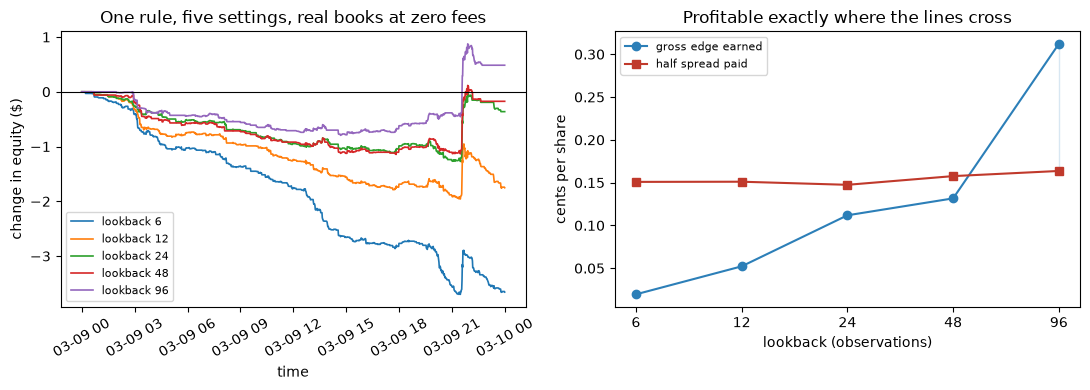

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for lookback in LOOKBACKS:
    curve = runs[lookback].equity.to_pandas().sort_values("ts")
    axes[0].plot(curve.ts, curve.equity - curve.equity.iloc[0], lw=1.2,
                 label=f"lookback {lookback}")
axes[0].axhline(0.0, color="black", lw=0.8)
axes[0].set_title("One rule, five settings, real books at zero fees")
axes[0].set_xlabel("time")
axes[0].set_ylabel("change in equity ($)")
axes[0].tick_params(axis="x", labelrotation=30)
axes[0].legend(fontsize=8)
axes[1].plot(sweep.lookback, sweep.gross_c_per_share, marker="o", color="#2c7fb8",
             label="gross edge earned")
axes[1].plot(sweep.lookback, sweep.cost_c_per_share, marker="s", color="#c0392b",
             label="half spread paid")
axes[1].fill_between(sweep.lookback, sweep.gross_c_per_share, sweep.cost_c_per_share,
                     where=sweep.gross_c_per_share >= sweep.cost_c_per_share,
                     color="#2c7fb8", alpha=0.18)
axes[1].set_xscale("log", base=2)
axes[1].set_xticks(list(LOOKBACKS))
axes[1].set_xticklabels([str(value) for value in LOOKBACKS])
axes[1].set_title("Profitable exactly where the lines cross")
axes[1].set_xlabel("lookback (observations)")
axes[1].set_ylabel("cents per share")
axes[1].legend(fontsize=8)
fig.tight_layout()

## Before believing any of it

One setting makes money, and this is the point in a research session where it is
easiest to fool yourself. So, plainly: **we tried five things and picked the best
one**, and the winner made 49 cents on 33 fills in a single day.

The **deflated Sharpe ratio** prices exactly that mistake. It computes the Sharpe
a worthless strategy would be expected to reach by luck given how many trials
produced it, then asks how likely the observed Sharpe is to beat that. Run it
twice — pretending we tried one setting, then telling the truth — because the
difference between those two numbers is the lesson.

In [19]:
best_lookback = int(sweep.sort_values("net_pnl", ascending=False).iloc[0].lookback)
best = runs[best_lookback]
curve = best.equity.to_pandas().sort_values("ts").equity.tolist()
returns = [
    (curve[i] - curve[i - 1]) / curve[i - 1] for i in range(1, len(curve)) if curve[i - 1]
]
winner = sweep.set_index("lookback").loc[best_lookback]
print(f"best setting: lookback {best_lookback}, "
      f"{int(winner.fills)} fills, {winner.net_pnl:+.2f}\n")
for claimed in (1, len(LOOKBACKS)):
    deflated = quant.deflated_sharpe(returns, trials=claimed)
    label = "if we pretend we tried 1" if claimed == 1 else f"admitting we tried {claimed}"
    print(f"{label:<28} sharpe {deflated.sharpe:+.4f}  "
          f"benchmark {deflated.benchmark:+.4f}  P(genuine) {deflated.probability:.3f}")

best setting: lookback 96, 33 fills, +0.49

if we pretend we tried 1     sharpe +0.0194  benchmark +0.0000  P(genuine) 0.764
admitting we tried 5         sharpe +0.0194  benchmark +0.0346  P(genuine) 0.285


Same run, same equity curve, same Sharpe. Claim one setting and it looks like a
76% chance of being real; admit five and it falls to 29%. Nobody applies this
correction for you — the trial count is a fact about your afternoon rather than
about your data.

There is a limit on what one day of six markets could show even in principle.
The panel includes three questions about the same Federal Reserve meeting, whose
outcomes are mechanically related, so the effective number of independent bets
is smaller than six.

## Settlement, and the gate that refuses it

One more thing the engine does on your behalf. Only one of these six markets
resolves inside the one-day capture, so a position held in any of the others
cannot be valued without information the replay never reached. The engine
refuses each one individually rather than marking it to the eventual winner.

In [20]:
capture_end = int(pd.Timestamp(panel.ts.max()).value)
inside = [spec for spec in specs if spec.settlement_observable_ns <= capture_end]
positions = best.positions.to_pandas()
print(f"markets resolving inside the capture: {len(inside)} of {len(specs)}")
print(f"positions still open at the end:      {len(positions)}")
print(f"of those, settled:                    {int(positions.settlement_pnl.notna().sum())}")
warning = best.run.to_pandas().warnings.iloc[0]
if isinstance(warning, str) and warning:
    print(f"\nthe engine's own words:\n  {warning.split(';')[0][:190]}")

markets resolving inside the capture: 1 of 6
positions still open at the end:      4
of those, settled:                    0

the engine's own words:
  0x25aa90b3cd98305e849189b4e8b770fc77fe89bccb7cf9656468414e01145d38 outcome 0 left unsettled: the run simulated through 1773100747971000000 but this market resolved at 1773792000000000000


Had those positions been marked to their eventual outcomes, this backtest would
have looked spectacular — the markets resolved weeks after the last book event
in the data. That is the most valuable-looking bug in prediction-market
research, and it is worth having a machine refuse it rather than remembering to.

## The run as one page

Everything above was assembled by hand: a table here, a chart there.
`result.report()` does it in one call, rendering the run as a self-contained
HTML document — no network access when opened, no dependencies — so it can be
attached to a review or opened in five years.

It is not a tearsheet. A tearsheet answers *how did the equity curve behave*;
this answers *should I believe these numbers, and what actually happened*, so it
leads with the replay fidelity, the pin, and the run's warnings before any
performance figure. Read the status banner first: it says `periodic L2
snapshots` rather than something reassuring, because that is the honest
description of what this capture supports.

In [21]:
report_path = Path(f"data/cache/polymarket-breakout-{best_lookback}.html")
document = best.report(report_path, title=f"Polymarket breakout, lookback {best_lookback}")
print(f"wrote {report_path} ({len(document) / 1024:.0f} KB, self-contained)")
display(best)

wrote data/cache/polymarket-breakout-96.html (266 KB, self-contained)


{'run_id': 'breakout-96',
 'fork': 'bt-breakout-96',
 'digest': '7389e630d504b61e2d20a5d5d0102e0676664ef6416d258b73123f5486b9fdd7',
 'starting_cash': 100000.0,
 'final_cash': 100000.45,
 'realized_pnl': 0.49,
 'commissions': 0.0,
 'funding_paid': 0.0,
 'fills': 33,
 'orders': 59,
 'records_processed': 9588,
 'simulated_through_ns': 1773100747971000000,
 'equity_points': 1186,
 'settlement_applied': False,
 'coverage': None,
 'liquidations': 0,
 'rejected_for_margin': 0,
 'self_trades_prevented': 0,
 'calibration_samples': [],
 'set_operations': [],
 'forecasts': 0,
 'mark_points': 7106,
 'expirations': [{'instrument_id': '0x4dfc31e647a10fafdc77e89826a93a85d1420981b7978ec8ce9ef04351ad1ec9',
   'ts': 1772928000000000000}],
 'metrics': {'orders_submitted': 59,
  'orders_filled': 33,
  'orders_cancelled_unfilled': 0,
  'orders_rejected_margin': 0,
  'orders_rejected_risk': 0,
  'orders_rejected_self_trade': 0,
  'orders_rejected_naked_short': 0,
  'orders_rejected_expired': 26,
  'orders_rejected_post_only': 0,
  'orders_triggered': 0,
  'twap_slices': 0,
  'fills_taker': 33,
  'fills_maker': 0,
  'book_gaps': 0,
  'liquidations': 0,
  'set_operations': 0,
  'set_operations_rejected': 0,
  'instruments_expired': 1},
 'warnings': ['0x25aa90b3cd98305e849189b4e8b770fc77fe89bccb7cf9656468414e01145d38 outcome 0 left unsettled: the run simulated through 1773100747971000000 but this market resolved at 1773792000000000000; booking it would be profit nobody trading this window could have collected'],
 'cached': False,
 'trial_digest': 'c8beecd7cd52f116df5895c3fcbea56c365d28829cecdfd13e5acbab9a96baef'}

## Reproducing it

The one claim that has to hold whatever the result is. `verify()` re-executes
the stored configuration against the same pin and compares every result table
row by row. A callback carries state, so it needs a **fresh instance** — the one
that just ran has a full history buffer and would not start from the same place.

In [22]:
verified = best.verify(strategy=Breakout(lookback=best_lookback))
print(f"verified:        {verified['verified']}")
print(f"tables compared: {list(verified['tables_equal'])}")
print(f"data pin:        {best.config.data.snapshot}")

verified:        True
tables compared: ['bt_orders', 'bt_fills', 'bt_positions', 'bt_equity']
data pin:        real-v1


In [23]:
db.close()

---

# What to take away

**The mid is not a price.** Polymarket is a plain limit order book: bids and
asks with sizes, and a gap between them where nothing trades. Buy at the ask and
sell at the bid and you have paid the spread, whatever the mid did in between.

**One number decides whether a strategy works.** Gross edge per share against
the half-spread it pays. The sweep varied only trading frequency and the sign of
the result flipped exactly where those two crossed. Trading more often did not
find more signal; it found the same signal and paid for it repeatedly.

**A losing backtest is diagnostic, not just disappointing.** Splitting the loss
into gross edge and spread said the idea had something in it and the execution
was destroying it — which points at trading less, or trading passively, rather
than at abandoning the signal.

**The trial count is part of the result.** The winning setting looked like a 76%
chance of being genuine until we admitted five settings were tried, at which
point it fell to 29%. That correction costs one line and nobody applies it for
you.

**Let the machine hold the caveats.** The settlement gate refused to value
positions whose outcomes were not yet knowable, `expiration_ns` refused 70
orders in a market that had already closed, the pin makes every run read
identical bytes, and `report()` puts the fidelity warning at the top of the page
rather than in a footnote the author has to remember.

## Where to go next

Things this tutorial deliberately left out, each worth its own article:

- **Signals tables versus callbacks.** A strategy can also be expressed as a
  table of timestamped order intents. That form gives up path-dependence but
  gains a content hash, which unlocks trial deduplication and `backtest.study`
  parameter searches — neither of which accepts a callback. The sweep above
  would have been a one-liner in that form.
- **Execution as a variable.** The same strategy under added latency, or posting
  passively instead of crossing, moves the result more than most strategy
  changes do.
- **Maker strategies and queue position**, which need delta-level data rather
  than the periodic snapshots used here. The engine refuses a
  `queue_position=True` claim on this capture rather than inventing a number.
- **Both sides of the book**, which would make the YES/NO parity trade testable.

The cookbook this article is drawn from is at
[h5i-db-cookbook](https://github.com/h5i-dev/h5i-db-cookbook), with longer
treatments of each in `notebooks/05_prediction_markets/`.